In [1]:
# Import data, plotting, evaluation, and project model utilities.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

from support_sense.baseline import build_baseline_pipeline
from support_sense.data_split import split_dataset
from support_sense.evaluation import (
    build_error_analysis,
    extract_confusion_pairs,
    get_top_features_by_class,
)
from support_sense.metrics import calculate_classification_metrics

In [2]:
# Locate the unchanged raw dataset.
DATA_PATH = Path("../data/support_tickets.csv")

In [3]:
# Load all labeled tickets.
df = pd.read_csv(DATA_PATH)

In [4]:
# Reproduce the exact same split from Milestone 4.
train_df, validation_df, test_df = split_dataset(df)

In [5]:
# Build the unchanged Milestone 5 baseline.
model = build_baseline_pipeline()

In [6]:
# Train using training data only.
model.fit(train_df["text"], train_df["category"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['account_access','billing','cancellation_refund','delivery', 'product_inquiry','technical_issue']"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


In [7]:
# Generate predictions for validation data only.
validation_predictions = model.predict(validation_df["text"])

In [8]:
# Calculate the same aggregate metrics used by baseline_001.
overall_metrics = calculate_classification_metrics(
    validation_df["category"], validation_predictions
)
overall_metrics

{'accuracy': 0.9777777777777777,
 'precision_macro': 0.9791666666666666,
 'recall_macro': 0.9791666666666666,
 'f1_macro': 0.9777777777777779}

In [9]:
# Generate precision, recall, F1, and support for every category
report = classification_report(
    validation_df["category"], validation_predictions, zero_division=0
)

print(report)

                     precision    recall  f1-score   support

     account_access       1.00      1.00      1.00         8
            billing       1.00      0.88      0.93         8
cancellation_refund       0.88      1.00      0.93         7
           delivery       1.00      1.00      1.00         7
    product_inquiry       1.00      1.00      1.00         7
    technical_issue       1.00      1.00      1.00         8

           accuracy                           0.98        45
          macro avg       0.98      0.98      0.98        45
       weighted avg       0.98      0.98      0.98        45



In [10]:
# Ask scikit-learn for structured report data instead of formatted text.
report_dict = classification_report(
    validation_df["category"], validation_predictions, output_dict=True, zero_division=0
)

In [11]:
# Convert the nested dictionary into a table.
report_df = pd.DataFrame(report_dict).transpose()

report_df

,precision,recall,f1-score,support
account_access,1.000000,1.000000,1.000000,8.000000
billing,1.000000,0.875000,0.933333,8.000000
cancellation_refund,0.875000,1.000000,0.933333,7.000000
delivery,1.000000,1.000000,1.000000,7.000000
product_inquiry,1.000000,1.000000,1.000000,7.000000
technical_issue,1.000000,1.000000,1.000000,8.000000
accuracy,0.977778,0.977778,0.977778,0.977778
macro avg,0.979167,0.979167,0.977778,45.000000
weighted avg,0.980556,0.977778,0.977778,45.000000


In [12]:
# Get the exact labels known by the trained classifier.
class_labels = model.named_steps["classifier"].classes_

class_labels

array(['account_access', 'billing', 'cancellation_refund', 'delivery',
       'product_inquiry', 'technical_issue'], dtype=object)

In [13]:
# Keep only actual ticket categories.
class_metrics_df = report_df.loc[class_labels]

class_metrics_df

,precision,recall,f1-score,support
account_access,1.000,1.000,1.000000,8.0
billing,1.000,0.875,0.933333,8.0
cancellation_refund,0.875,1.000,0.933333,7.0
delivery,1.000,1.000,1.000000,7.0
product_inquiry,1.000,1.000,1.000000,7.0
technical_issue,1.000,1.000,1.000000,8.0


In [14]:
# Return the first category tied for the highest individual F1 score.
best_category = class_metrics_df["f1-score"].idxmax()

best_f1 = class_metrics_df.loc[
    best_category,
    "f1-score",
]

print("Best category:", best_category)
print("F1:", best_f1)

Best category: account_access
F1: 1.0


In [15]:
# Return the first category tied for the lowest individual F1 score.
worst_category = class_metrics_df["f1-score"].idxmin()

worst_f1 = class_metrics_df.loc[
    worst_category,
    "f1-score",
]

print("Worst category:", worst_category)
print("F1:", worst_f1)

Worst category: billing
F1: 0.9333333333333333


In [16]:
# Fix the label order so rows and columns remain easy to interpret.
labels = list(class_labels)

In [17]:
# Rows represent actual categories.
# Columns represent predicted categories.
confusion = confusion_matrix(
    validation_df["category"], validation_predictions, labels=labels
)

confusion

array([[8, 0, 0, 0, 0, 0],
       [0, 7, 1, 0, 0, 0],
       [0, 0, 7, 0, 0, 0],
       [0, 0, 0, 7, 0, 0],
       [0, 0, 0, 0, 7, 0],
       [0, 0, 0, 0, 0, 8]])

In [18]:
# Add category names to both axes.
confusion_df = pd.DataFrame(confusion, index=labels, columns=labels)

confusion_df

,account_access,billing,cancellation_refund,delivery,product_inquiry,technical_issue
account_access,8,0,0,0,0,0
billing,0,7,1,0,0,0
cancellation_refund,0,0,7,0,0,0
delivery,0,0,0,7,0,0
product_inquiry,0,0,0,0,7,0
technical_issue,0,0,0,0,0,8


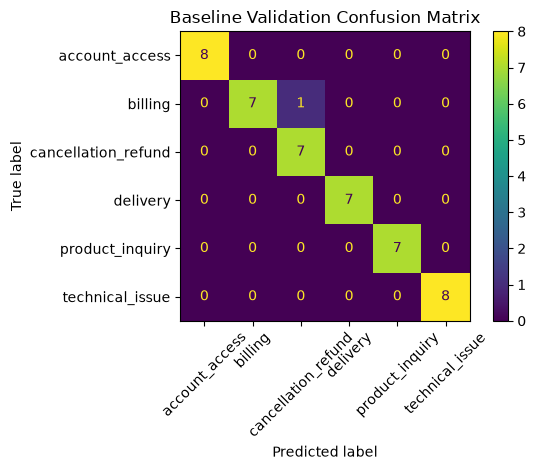

In [19]:
# Generate the visualization from predictions we already computed.
ConfusionMatrixDisplay.from_predictions(
    validation_df["category"],
    validation_predictions,
    labels=labels,
    xticks_rotation=45,
)

plt.title("Baseline Validation Confusion Matrix")
plt.tight_layout()
plt.show()

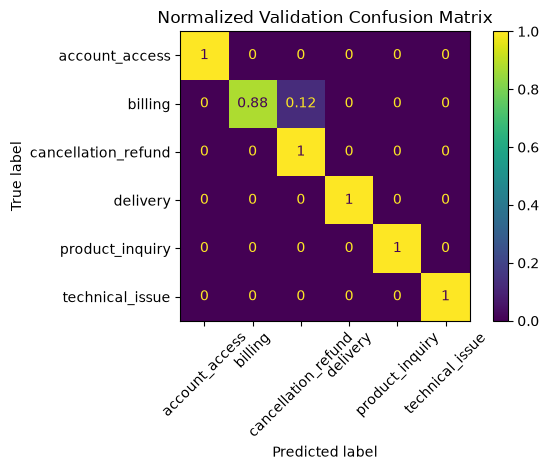

In [20]:
# Normalize each true-class row independently.
ConfusionMatrixDisplay.from_predictions(
    validation_df["category"],
    validation_predictions,
    labels=labels,
    normalize="true",
    xticks_rotation=45,
)

plt.title("Normalized Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [21]:
# Return class-to-class mistakes ordered by frequency.
confusion_pairs = extract_confusion_pairs(confusion_df)

confusion_pairs

,actual_category,predicted_category,count
0,billing,cancellation_refund,1


In [22]:
# Get one probability distribution per validation ticket.
probabilities = model.predict_proba(validation_df["text"])

probabilities.shape

(45, 6)

In [23]:
# The first validation example has one probability for every class.
probabilities[0]

array([0.09300732, 0.50524259, 0.10555872, 0.12685762, 0.08163723,
       0.08769652])

In [24]:
# Re-display the class order used by the probability columns.
class_labels

array(['account_access', 'billing', 'cancellation_refund', 'delivery',
       'product_inquiry', 'technical_issue'], dtype=object)

In [25]:
# Store the maximum class probability for every ticket.
prediction_confidence = probabilities.max(axis=1)

prediction_confidence

array([0.50524259, 0.3456879 , 0.37493657, 0.44781193, 0.40116382,
       0.56984537, 0.4478322 , 0.33993507, 0.24469465, 0.55187865,
       0.63998873, 0.31621588, 0.43227836, 0.46352006, 0.33999595,
       0.27028673, 0.35841809, 0.40666327, 0.54266398, 0.46742676,
       0.59619197, 0.61942402, 0.37780905, 0.56866171, 0.41077606,
       0.48303592, 0.50219227, 0.53739588, 0.50485864, 0.35349428,
       0.28119206, 0.27944665, 0.36785926, 0.27329733, 0.42245024,
       0.45832514, 0.65710721, 0.31796283, 0.5382184 , 0.29488098,
       0.34129117, 0.56992582, 0.43897507, 0.33910418, 0.45022331])

In [26]:
# Start with the original validation records.
prediction_analysis = validation_df[
    [
        "ticket_id",
        "text",
        "category",
    ]
].copy()

In [27]:
# Rename the ground-truth target for clarity.
prediction_analysis = prediction_analysis.rename(
    columns={"category": "actual_category"}
)

In [28]:
# Attach model output.
prediction_analysis["predicted_category"] = validation_predictions

In [29]:
# Attach the probability of the selected class.
prediction_analysis["confidence"] = prediction_confidence

In [30]:
# Explicitly mark whether the prediction was correct.
prediction_analysis["is_correct"] = (
    prediction_analysis["actual_category"] == prediction_analysis["predicted_category"]
)

In [31]:
# Preview the combined actual labels, predictions, confidence, and outcomes.
prediction_analysis.head()

,ticket_id,text,actual_category,predicted_category,confidence,is_correct
0,TKT-1045,"Hello support, I do not recognize this charge....",billing,billing,0.505243,True
1,TKT-1089,"Hi, I forgot which email I used to sign up. I ...",account_access,account_access,0.345688,True
2,TKT-1048,"Hey team, I was billed after changing my plan....",billing,billing,0.374937,True
3,TKT-1137,"Hello support, The app crashes whenever I open...",technical_issue,technical_issue,0.447812,True
4,TKT-1209,"Hi there, Please refund my latest payment. Thi...",cancellation_refund,cancellation_refund,0.401164,True


In [32]:
# Keep only validation mistakes for manual inspection.
errors_df = prediction_analysis[~prediction_analysis["is_correct"]].copy()

errors_df

,ticket_id,text,actual_category,predicted_category,confidence,is_correct
30,TKT-1010,"Good day, I was charged twice for my subscript...",billing,cancellation_refund,0.281192,False


In [33]:
# Inspect mistakes the model was most certain about first.
errors_df = errors_df.sort_values("confidence", ascending=False)

errors_df[["text", "actual_category", "predicted_category", "confidence"]]

,text,actual_category,predicted_category,confidence
30,"Good day, I was charged twice for my subscript...",billing,cancellation_refund,0.281192


In [34]:
# Choose where the manually annotated validation errors will be saved.
ERROR_REPORT_PATH = Path("../reports/error_analysis.csv")

In [35]:
# Record a human interpretation of why the only error may have occurred.
errors_df["analyst_notes"] = (
    "It mentions charged twice so model predicted that it should refund the second charged"
)

In [36]:
# Persist only the fields needed for manual error analysis.
errors_df[
    [
        "ticket_id",
        "text",
        "actual_category",
        "predicted_category",
        "confidence",
        "analyst_notes",
    ]
].to_csv(
    ERROR_REPORT_PATH,
    index=False,
)

In [37]:
# Confirm the report can be read back successfully.
pd.read_csv(ERROR_REPORT_PATH).head()

,ticket_id,text,actual_category,predicted_category,confidence,analyst_notes
0,TKT-1010,"Good day, I was charged twice for my subscript...",billing,cancellation_refund,0.281192,It mentions charged twice so model predicted t...


In [38]:
# Access the two fitted components.
vectorizer = model.named_steps["tfidf"]
classifier = model.named_steps["classifier"]

# TF-IDF feature names and Logistic Regression coefficients
# align by feature column.
feature_names = vectorizer.get_feature_names_out()
coefficients = classifier.coef_

print(feature_names.shape)
print(coefficients.shape)

(252,)
(6, 252)


In [39]:
# Display the ten terms with the strongest positive coefficient per category.

top_features = get_top_features_by_class(
    model,
    top_n=10,
)

for category, features in top_features.items():
    print(f"\n{category}")

    for term, coefficient in features:
        print(f"{term:20} {coefficient:.4f}")


account_access
account              1.4214
cannot               1.3568
code                 1.2382
two                  1.0319
factor               1.0319
sending              1.0319
authentication       1.0319
disabled             1.0191
unexpectedly         1.0191
email                0.8169

billing
recognize            1.3983
charge               1.3983
was                  1.3329
invoice              1.1810
billed               0.7893
changing             0.7893
applied              0.7688
copy                 0.7155
elsewhere            0.7132
even                 0.7132

cancellation_refund
refund               2.1576
want                 1.4803
cancel               1.2835
renewal              1.0437
stop                 1.0437
to                   1.0342
cancelled            0.9536
still                0.9536
expected             0.7900
lower                0.7900

delivery
package              1.4016
address              1.3734
dispatch             1.0999
shipping            

In [40]:
# Recreate the error table through the reusable project helper.
errors_df = build_error_analysis(
    validation_df,
    model,
)

errors_df

,ticket_id,text,actual_category,predicted_category,confidence
0,TKT-1010,"Good day, I was charged twice for my subscript...",billing,cancellation_refund,0.281192


In [41]:
# Choose where the complete per-class metric table will be saved.
CLASSIFICATION_REPORT_PATH = Path("../reports/classification_report.csv")

In [42]:
# Preserve category-level metrics for later model comparisons.
report_df.to_csv(
    CLASSIFICATION_REPORT_PATH,
)

In [43]:
# Choose the confusion-pair report path and persist the observed mistakes.
CONFUSION_PAIRS_PATH = Path("../reports/confusion_pairs.csv")

confusion_pairs.to_csv(
    CONFUSION_PAIRS_PATH,
    index=False,
)

## Evaluation Findings

### Overall performance

- **Accuracy:** 0.9778 (97.78%; 44 of 45 tickets)
- **Macro precision:** 0.9792 (97.92%)
- **Macro recall:** 0.9792 (97.92%)
- **Macro F1:** 0.9778 (97.78%)

The closely aligned accuracy and macro-averaged scores show that performance is strong across categories rather than being dominated by a single class.

### Best-performing categories

`account_access`, `delivery`, `product_inquiry`, and `technical_issue` tie for best performance, each with **1.0000 precision, recall, and F1**. The code's `idxmax()` returns `account_access` because it is the first tied row, not because its score exceeds the other three. These categories contain distinctive learned terms such as `authentication`, `package`, `plan`, and `screen`, which likely make them easier to separate in this dataset. Their validation supports are only 7 or 8 records, however, so a perfect score is not yet strong evidence of perfect generalization.

### Worst-performing categories

`billing` and `cancellation_refund` tie for the lowest F1 at **0.9333**. `billing` has **1.0000 precision** and **0.8750 recall**, while `cancellation_refund` has **0.8750 precision** and **1.0000 recall**. Their shared payment, charge, cancellation, and refund vocabulary creates a natural decision boundary overlap.

### Most common confusion

- **Actual:** `billing`
- **Predicted:** `cancellation_refund`
- **Number of examples:** 1

This is the only off-diagonal confusion in the validation matrix.

### Error-analysis observations

1. The only error is ticket `TKT-1010`, whose actual category is `billing` but whose predicted category is `cancellation_refund`. The phrase *charged twice* clearly describes a billing problem but also implies that the customer may want money refunded.
2. The selected-class confidence is only **0.2812**, so the model was appropriately uncertain rather than confidently wrong. This makes the ticket a good candidate for manual review or a low-confidence routing rule.
3. One error changes accuracy by **2.22 percentage points** because the validation set has only 45 records. The dataset is also strongly templated, so the excellent score should be confirmed on more varied tickets before drawing production-level conclusions.

### Vocabulary / feature observations

Strong positive associations are intuitive for most categories:

- `account_access`: `account`, `cannot`, `code`, `authentication`, `disabled`
- `billing`: `recognize`, `charge`, `invoice`, `billed`
- `cancellation_refund`: `refund`, `want`, `cancel`, `renewal`
- `delivery`: `package`, `address`, `shipping`, `delivered`
- `product_inquiry`: `plan`, `service`, `devices`, `team`
- `technical_issue`: `screen`, `freezes`, `checkout`, `dark`

Potentially misleading features include generic words such as `was`, `to`, `you`, and `are`. The term `two` is strongly associated with account access because of *two-factor authentication*, but the token alone may be ambiguous in other numerical contexts. The vectorizer also treats `charge` and `charged` as different features; the learned `charge` feature strongly supports billing, while the sole misclassified ticket uses `charged`. Because unigram coefficients ignore morphology and phrase context, these weights should be treated as associations rather than causal explanations.

### Hypotheses for the next milestone

1. Adding word bigrams or character n-grams may capture phrases such as *charged twice*, *two-factor authentication*, and *cancel renewal*, reducing ambiguity that unigram features cannot represent.
2. Lemmatization or character n-grams may let related forms such as `charge` and `charged` share evidence. TF-IDF settings, selective stop-word removal, and Logistic Regression regularization should be compared with stratified cross-validation rather than assumed to help.
3. More varied examples and clearer labeling guidance are needed around the `billing` versus `cancellation_refund` boundary. A calibrated low-confidence threshold could route uncertain tickets for human review. Before final test evaluation, the known duplicate text crossing the training and test subsets must also be grouped or removed.